In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("logistics_shipment_dataset.csv")

print(df.head())
print("Dataset shape:", df.shape)

Saving logistics_shipment_dataset.csv to logistics_shipment_dataset.csv
  Shipment_ID     Origin Destination  Warehouse          Pickup_Time  \
0     SHP0001    Chennai       Kochi  Bengaluru  2026-01-16 17:17:00   
1     SHP0002  Hyderabad   Hyderabad  Hyderabad  2026-03-23 07:59:00   
2     SHP0003    Chennai      Mumbai  Hyderabad  2026-05-18 00:45:00   
3     SHP0004    Chennai  Coimbatore    Chennai  2026-05-04 19:35:00   
4     SHP0005  Hyderabad       Delhi  Hyderabad  2026-06-11 21:44:00   

                 Sorting_Time               Dispatch_Time  \
0  2026-01-17 00:33:42.566529  2026-01-17 04:48:57.239204   
1  2026-03-23 14:00:03.916083  2026-03-23 19:28:34.859220   
2  2026-05-18 07:16:24.435907  2026-05-18 11:16:45.310488   
3  2026-05-04 23:54:34.588232  2026-05-05 07:02:20.010364   
4  2026-06-12 05:57:20.400706  2026-06-12 10:54:33.899040   

                Delivery_Time  Transit_Time Transport_Mode Delivery_Status  \
0  2026-01-19 21:54:00.942118         76.62       

In [4]:
# Display basic information
print("Dataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Convert timestamp columns to datetime
date_columns = [
    "Pickup_Time",
    "Sorting_Time",
    "Dispatch_Time",
    "Delivery_Time"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Remove rows with missing essential information
df = df.dropna(subset=date_columns + [
    "Shipment_ID", "Warehouse", "Transport_Mode",
    "Delivery_Status"
])

# Check for invalid timestamp sequences
valid = (
    (df["Pickup_Time"] <= df["Sorting_Time"]) &
    (df["Sorting_Time"] <= df["Dispatch_Time"]) &
    (df["Dispatch_Time"] <= df["Delivery_Time"])
)

df = df[valid].copy()

# Check data types and final shape
print("\nCleaned Dataset Shape:", df.shape)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Shipment_ID      1000 non-null   object 
 1   Origin           1000 non-null   object 
 2   Destination      1000 non-null   object 
 3   Warehouse        1000 non-null   object 
 4   Pickup_Time      1000 non-null   object 
 5   Sorting_Time     1000 non-null   object 
 6   Dispatch_Time    1000 non-null   object 
 7   Delivery_Time    1000 non-null   object 
 8   Transit_Time     1000 non-null   float64
 9   Transport_Mode   1000 non-null   object 
 10  Delivery_Status  1000 non-null   object 
 11  Shipment_Volume  1000 non-null   int64  
dtypes: float64(1), int64(1), object(10)
memory usage: 93.9+ KB

Missing Values:
Shipment_ID        0
Origin             0
Destination        0
Warehouse          0
Pickup_Time        0
Sorting_Time       0
Dispatch_Time      0
D

In [5]:
# Calculate time in hours
df["Sorting_Hours"] = (
    df["Sorting_Time"] - df["Pickup_Time"]
).dt.total_seconds() / 3600

df["Dispatch_Wait_Hours"] = (
    df["Dispatch_Time"] - df["Sorting_Time"]
).dt.total_seconds() / 3600

df["Transportation_Hours"] = (
    df["Delivery_Time"] - df["Dispatch_Time"]
).dt.total_seconds() / 3600

df["Total_Delivery_Hours"] = (
    df["Delivery_Time"] - df["Pickup_Time"]
).dt.total_seconds() / 3600

# Display stage durations
print(df[[
    "Shipment_ID",
    "Sorting_Hours",
    "Dispatch_Wait_Hours",
    "Transportation_Hours",
    "Total_Delivery_Hours"
]].head(10))

# Calculate average stage durations
print("\nAverage Time at Each Stage:")
print(df[[
    "Sorting_Hours",
    "Dispatch_Wait_Hours",
    "Transportation_Hours"
]].mean().round(2))

  Shipment_ID  Sorting_Hours  Dispatch_Wait_Hours  Transportation_Hours  \
0     SHP0001       7.278491             4.254076             65.084362   
1     SHP0002       6.017754             5.475262             21.728308   
2     SHP0003       6.523454             4.005798             22.988419   
3     SHP0004       4.326275             7.129284              8.787055   
4     SHP0005       8.222334             4.953750             31.207123   
5     SHP0006       5.133925             2.246635              4.880672   
6     SHP0007       3.830616             5.088074              7.739941   
7     SHP0008       5.984737             6.940234             35.329645   
8     SHP0009       5.249071             6.014240             56.595820   
9     SHP0010       1.448324             3.429792             18.428676   

   Total_Delivery_Hours  
0             76.616928  
1             33.221324  
2             33.517672  
3             20.242613  
4             44.383206  
5             12.2

In [6]:
# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe())

# Delivery status counts
print("\nDelivery Status:")
print(df["Delivery_Status"].value_counts())

# Average delivery time by warehouse
print("\nAverage Delivery Time by Warehouse:")
print(
    df.groupby("Warehouse")["Total_Delivery_Hours"]
    .mean()
    .sort_values(ascending=False)
)

# Average delivery time by transport mode
print("\nAverage Delivery Time by Transport Mode:")
print(
    df.groupby("Transport_Mode")["Total_Delivery_Hours"]
    .mean()
    .sort_values(ascending=False)
)

# Delayed shipments by warehouse
print("\nDelayed Shipments by Warehouse:")
print(
    df[df["Delivery_Status"] == "Delayed"]
    .groupby("Warehouse")
    .size()
    .sort_values(ascending=False)
)

Descriptive Statistics:
                      Pickup_Time                   Sorting_Time  \
count                        1000                           1000   
mean   2026-03-30 13:50:26.520000  2026-03-30 21:01:26.086042880   
min           2026-01-01 12:37:00     2026-01-01 20:56:47.294450   
25%           2026-02-12 19:32:30  2026-02-12 23:12:08.125494784   
50%           2026-03-28 01:56:30  2026-03-28 07:53:18.235559680   
75%           2026-05-16 00:57:15  2026-05-16 06:02:13.122473984   
max           2026-06-30 04:06:00     2026-06-30 14:56:43.509316   
std                           NaN                            NaN   

                       Dispatch_Time                  Delivery_Time  \
count                           1000                           1000   
mean   2026-03-31 01:36:26.199054592  2026-04-01 08:20:55.829840640   
min       2026-01-02 00:34:53.210575     2026-01-02 13:43:47.353000   
25%    2026-02-13 05:21:58.999153664  2026-02-14 13:36:25.156113408   
50%    2

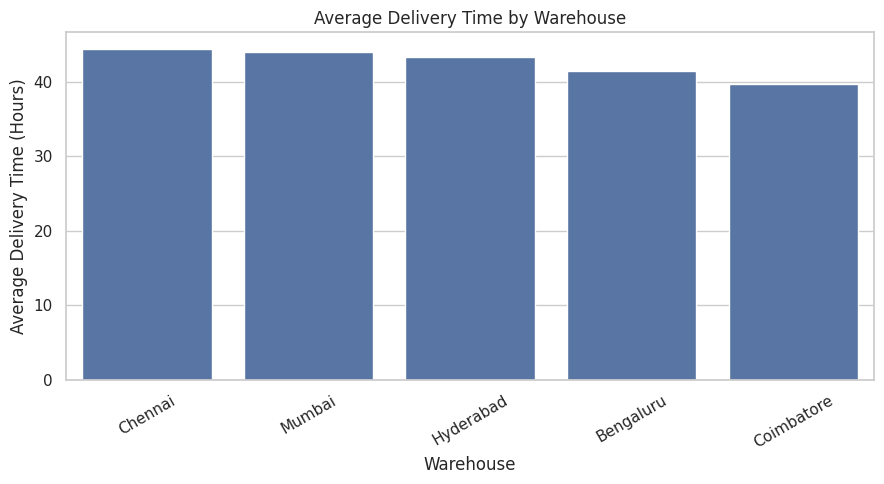

In [7]:
warehouse_delay = (
    df.groupby("Warehouse")["Total_Delivery_Hours"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=warehouse_delay.index,
    y=warehouse_delay.values
)

plt.title("Average Delivery Time by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

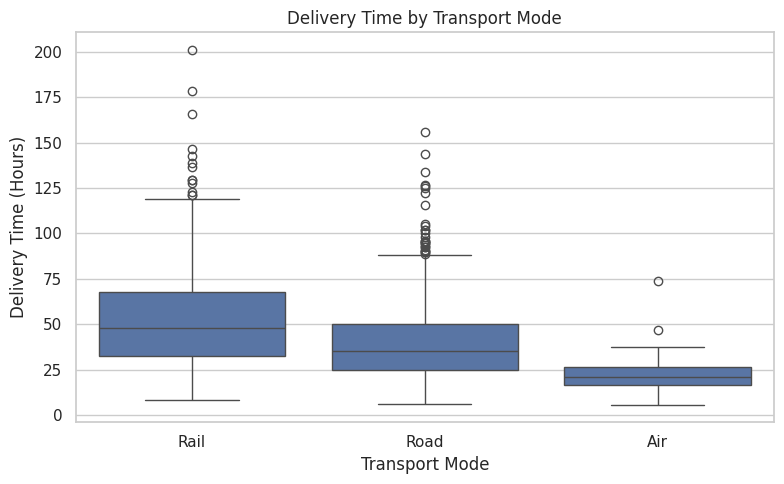

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Transport_Mode",
    y="Total_Delivery_Hours"
)

plt.title("Delivery Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Delivery Time (Hours)")
plt.tight_layout()
plt.show()

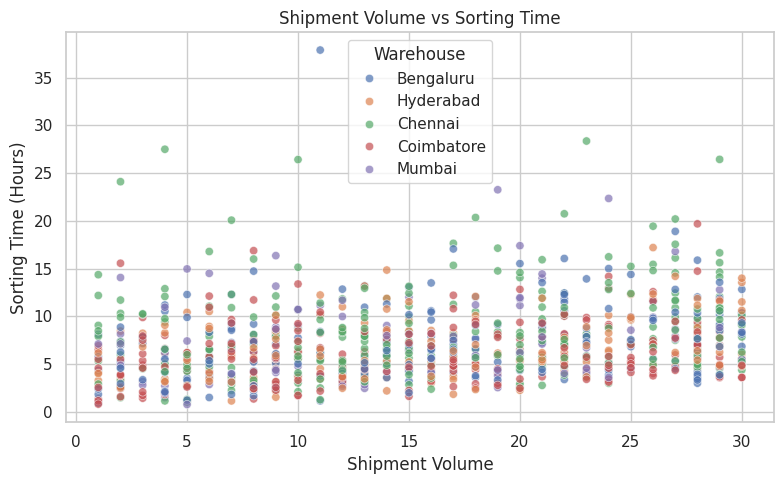

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Shipment_Volume",
    y="Sorting_Hours",
    hue="Warehouse",
    alpha=0.7
)

plt.title("Shipment Volume vs Sorting Time")
plt.xlabel("Shipment Volume")
plt.ylabel("Sorting Time (Hours)")
plt.tight_layout()
plt.show()

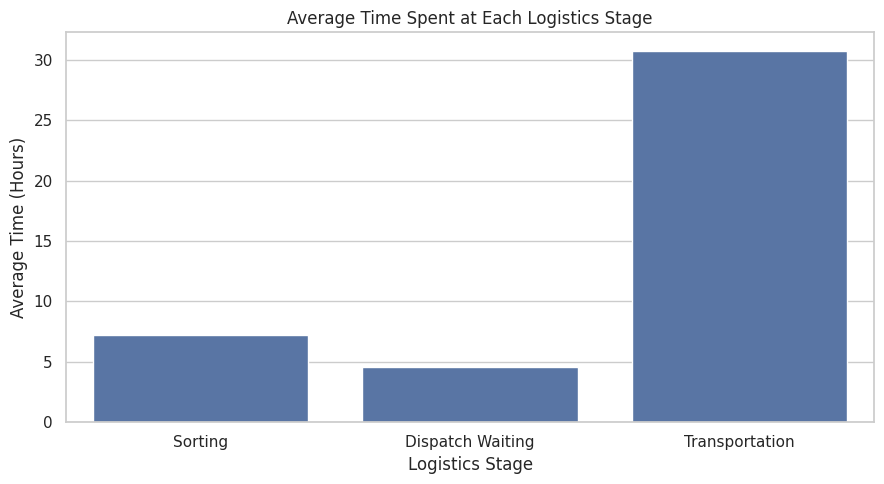

In [10]:
stage_times = pd.DataFrame({
    "Stage": [
        "Sorting",
        "Dispatch Waiting",
        "Transportation"
    ],
    "Average_Hours": [
        df["Sorting_Hours"].mean(),
        df["Dispatch_Wait_Hours"].mean(),
        df["Transportation_Hours"].mean()
    ]
})

plt.figure(figsize=(9, 5))

sns.barplot(
    data=stage_times,
    x="Stage",
    y="Average_Hours"
)

plt.title("Average Time Spent at Each Logistics Stage")
plt.xlabel("Logistics Stage")
plt.ylabel("Average Time (Hours)")
plt.tight_layout()
plt.show()

In [11]:
# Average time at each stage
bottlenecks = pd.Series({
    "Sorting": df["Sorting_Hours"].mean(),
    "Dispatch Waiting": df["Dispatch_Wait_Hours"].mean(),
    "Transportation": df["Transportation_Hours"].mean()
})

print("Average Stage Duration:")
print(bottlenecks.sort_values(ascending=False).round(2))

print("\nLongest Average Stage:")
print(bottlenecks.idxmax())

# Warehouse delay analysis
warehouse_analysis = df.groupby("Warehouse").agg(
    Total_Shipments=("Shipment_ID", "count"),
    Delayed_Shipments=(
        "Delivery_Status",
        lambda x: (x == "Delayed").sum()
    ),
    Average_Delivery_Hours=("Total_Delivery_Hours", "mean")
)

warehouse_analysis["Delay_Percentage"] = (
    warehouse_analysis["Delayed_Shipments"] /
    warehouse_analysis["Total_Shipments"] * 100
)

warehouse_analysis = warehouse_analysis.sort_values(
    "Delay_Percentage", ascending=False
)

print("\nWarehouse Bottleneck Analysis:")
print(warehouse_analysis.round(2))

Average Stage Duration:
Transportation      30.74
Sorting              7.18
Dispatch Waiting     4.58
dtype: float64

Longest Average Stage:
Transportation

Warehouse Bottleneck Analysis:
            Total_Shipments  Delayed_Shipments  Average_Delivery_Hours  \
Warehouse                                                                
Chennai                 294                131                   44.40   
Mumbai                   96                 39                   43.93   
Bengaluru               214                 85                   41.49   
Hyderabad               175                 61                   43.30   
Coimbatore              221                 73                   39.74   

            Delay_Percentage  
Warehouse                     
Chennai                44.56  
Mumbai                 40.62  
Bengaluru              39.72  
Hyderabad              34.86  
Coimbatore             33.03  


In [12]:
correlation = df[
    ["Shipment_Volume", "Sorting_Hours"]
].corr().iloc[0, 1]

print("Correlation between Shipment Volume and Sorting Time:")
print(round(correlation, 3))

if correlation > 0:
    print("Positive relationship: larger shipments tend to take longer to sort.")
elif correlation < 0:
    print("Negative relationship: larger shipments tend to take less time to sort.")
else:
    print("No linear relationship detected.")

Correlation between Shipment Volume and Sorting Time:
0.227
Positive relationship: larger shipments tend to take longer to sort.


In [13]:
# Create a binary target variable
df["Delayed"] = (
    df["Delivery_Status"] == "Delayed"
).astype(int)

# Select input features
features = [
    "Origin",
    "Destination",
    "Warehouse",
    "Transport_Mode",
    "Shipment_Volume",
    "Sorting_Hours",
    "Dispatch_Wait_Hours",
    "Transportation_Hours"
]

X = df[features].copy()
y = df["Delayed"]

# Convert categorical variables into numerical values
X = pd.get_dummies(
    X,
    columns=[
        "Origin",
        "Destination",
        "Warehouse",
        "Transport_Mode"
    ],
    dtype=int
)

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


MODEL EVALUATION
-------------------------
Accuracy: 0.935

Classification Report:
              precision    recall  f1-score   support

     On Time       0.91      0.99      0.95       122
     Delayed       0.99      0.85      0.91        78

    accuracy                           0.94       200
   macro avg       0.95      0.92      0.93       200
weighted avg       0.94      0.94      0.93       200

ROC-AUC: 0.9934


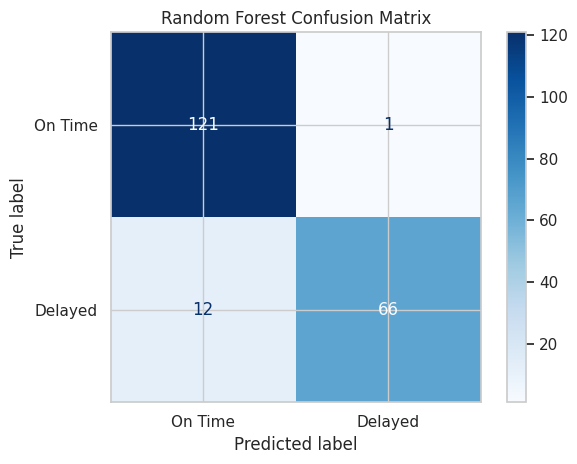

In [14]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

print("MODEL EVALUATION")
print("-------------------------")
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["On Time", "Delayed"],
    zero_division=0
))

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(auc, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On Time", "Delayed"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

Top 10 Important Features:
                 Feature  Importance
3   Transportation_Hours    0.543300
1          Sorting_Hours    0.084445
2    Dispatch_Wait_Hours    0.077088
0        Shipment_Volume    0.050828
27    Transport_Mode_Air    0.036797
29   Transport_Mode_Road    0.025232
28   Transport_Mode_Rail    0.021054
23     Warehouse_Chennai    0.010293
22   Warehouse_Bengaluru    0.010125
5         Origin_Chennai    0.009171


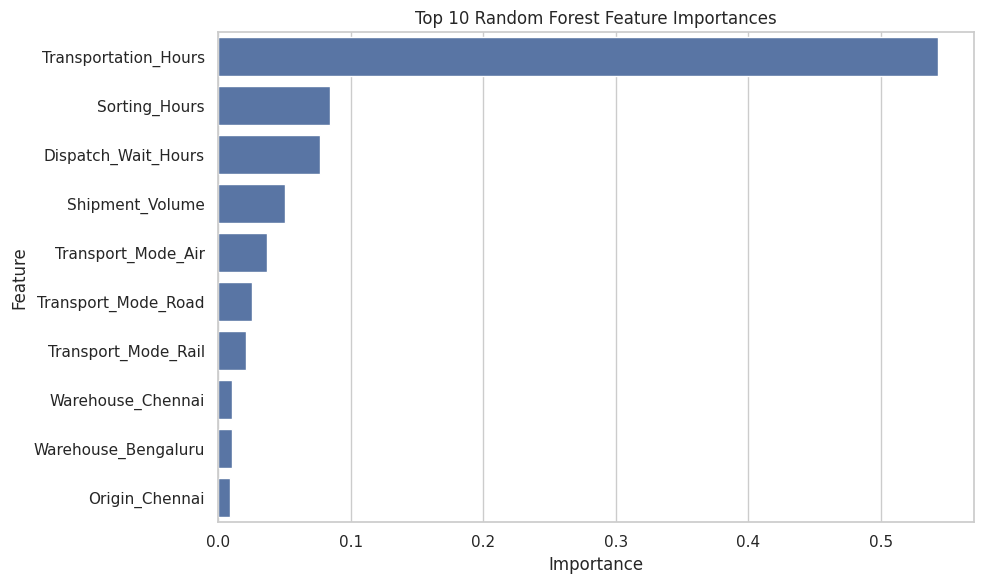

In [15]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
# Warehouse with the highest average delivery time
slowest_warehouse = (
    df.groupby("Warehouse")["Total_Delivery_Hours"]
    .mean()
    .idxmax()
)

slowest_warehouse_time = (
    df.groupby("Warehouse")["Total_Delivery_Hours"]
    .mean().max()
)

# Transport mode with the highest average delivery time
slowest_mode = (
    df.groupby("Transport_Mode")["Total_Delivery_Hours"]
    .mean()
    .idxmax()
)

slowest_mode_time = (
    df.groupby("Transport_Mode")["Total_Delivery_Hours"]
    .mean().max()
)

# Stage with the highest average duration
longest_stage = bottlenecks.idxmax()
longest_stage_time = bottlenecks.max()

# Overall delay percentage
delay_percentage = df["Delayed"].mean() * 100

# Shipment volume correlation
volume_corr = df["Shipment_Volume"].corr(
    df["Sorting_Hours"]
)

# Warehouse with highest delay percentage
highest_delay_warehouse = warehouse_analysis[
    "Delay_Percentage"
].idxmax()

highest_delay_rate = warehouse_analysis[
    "Delay_Percentage"
].max()

# Print key insights
print("KEY INSIGHTS")

print(
    f"1. {delay_percentage:.2f}% of shipments were delayed."
)

print(
    f"2. {slowest_warehouse} had the highest average "
    f"delivery time ({slowest_warehouse_time:.2f} hours)."
)

print(
    f"3. {slowest_mode} had the highest average "
    f"delivery time ({slowest_mode_time:.2f} hours)."
)

print(
    f"4. {longest_stage} was the longest stage, "
    f"averaging {longest_stage_time:.2f} hours."
)

print(
    f"5. {highest_delay_warehouse} had the highest "
    f"delay percentage ({highest_delay_rate:.2f}%)."
)

print(
    f"6. The correlation between shipment volume and "
    f"sorting time was {volume_corr:.3f}."
)

print(
    f"7. The Random Forest model achieved "
    f"{accuracy * 100:.2f}% accuracy and "
    f"{auc:.3f} ROC-AUC on the test set."
)

KEY INSIGHTS
1. 38.90% of shipments were delayed.
2. Chennai had the highest average delivery time (44.40 hours).
3. Rail had the highest average delivery time (55.18 hours).
4. Transportation was the longest stage, averaging 30.74 hours.
5. Chennai had the highest delay percentage (44.56%).
6. The correlation between shipment volume and sorting time was 0.227.
7. The Random Forest model achieved 93.50% accuracy and 0.993 ROC-AUC on the test set.


In [19]:
print("PRACTICAL ACTION PLAN")

print(
    f"1. Investigate {slowest_warehouse} because it has "
    "the longest average delivery time."
)

print(
    f"2. Review the {longest_stage.lower()} process "
    "because it has the longest average duration."
)

print(
    f"3. Examine the operational processes for "
    f"{highest_delay_warehouse}, which has the "
    "highest delay percentage."
)

print(
    f"4. Review transport planning for {slowest_mode} "
    "shipments to understand their longer delivery times."
)

if volume_corr > 0.3:
    print(
        "5. Investigate sorting capacity and staffing "
        "for high-volume shipments."
    )
else:
    print(
        "5. Examine other factors affecting sorting time, "
        "as volume has a limited linear relationship "
        "with sorting time."
    )

print(
    "6. Monitor delivery times and delay percentages "
    "regularly to measure improvements."
)

print(
    "7. Validate the Random Forest model on future "
    "shipments before using it operationally."
)

PRACTICAL ACTION PLAN
1. Investigate Chennai because it has the longest average delivery time.
2. Review the transportation process because it has the longest average duration.
3. Examine the operational processes for Chennai, which has the highest delay percentage.
4. Review transport planning for Rail shipments to understand their longer delivery times.
5. Examine other factors affecting sorting time, as volume has a limited linear relationship with sorting time.
6. Monitor delivery times and delay percentages regularly to measure improvements.
7. Validate the Random Forest model on future shipments before using it operationally.


In [20]:
# Save cleaned dataset
df.to_csv("cleaned_logistics_data.csv", index=False)

# Save warehouse analysis
warehouse_analysis.to_csv("warehouse_delay_analysis.csv")

# Save feature importance
importance.to_csv("feature_importance.csv", index=False)

# Save model
import joblib
joblib.dump(rf_model, "random_forest_model.pkl")

print("All project files saved successfully!")

All project files saved successfully!


In [21]:
from google.colab import files

files.download("cleaned_logistics_data.csv")
files.download("warehouse_delay_analysis.csv")
files.download("feature_importance.csv")
files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>